# Import Package

In [1]:
!pip install transformers==4.44.0
!pip install peft==0.12.0
!pip install trl==0.10.1
!pip install datasets accelerate bitsandbytes matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 59.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 49.2 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.11.0
    Uninstalling huggingface_hub-1.11.0:
      Successfully uninstalled huggingface_hub-1.11.0
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.4/296.4 kB 11.5 MB/s eta 0:00:00
  Attempting uninstall: peft
    Found existing installation: peft

# Loggin Hugging Face

In [2]:
from huggingface_hub import login
login()

# Test GPU

In [3]:
import torch
print(torch.cuda.get_device_name(0))

Tesla T4


# Load Base Model

In [4]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

model_name = "Qwen/Qwen2.5-0.5B"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto",
    torch_dtype=torch.float16
)

model.enable_input_require_grads()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/681 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

#Test Base Model

In [5]:
prompt = "Buatkan resep nasi goreng dalam 5 langkah sederhana"

inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

outputs = model.generate(
    **inputs,
    max_new_tokens=100
)

print(tokenizer.decode(outputs[0], skip_special_tokens=True))

Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


Buatkan resep nasi goreng dalam 5 langkah sederhana yang mudah dan praktis untuk dimakan bersama keluarga. Nasi goreng adalah salah satu menu yang sangat populer di Indonesia. Nasi goreng memiliki tekstur yang lembut dan menggugah selera. Di Indonesia, nasi goreng biasanya dibuat dengan bahan-bahan asam dan gula. Namun, ada juga resep nasi goreng yang menggunakan bahan asam dan gula yang lebih lezat. Berikut ini


#Load Dataset

In [6]:
from datasets import load_dataset

dataset = load_dataset(
    "indonlp/cendol_collection_v2",
    split="train[:1000]"
)

README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/23 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/23 [00:00<?, ?it/s]

data/train-00000-of-00023.parquet:   0%|          | 0.00/114M [00:00<?, ?B/s]

data/train-00001-of-00023.parquet:   0%|          | 0.00/93.1M [00:00<?, ?B/s]

...

data/train-00019-of-00023.parquet:   0%|          | 0.00/99.4M [00:00<?, ?B/s]

data/train-00020-of-00023.parquet:   0%|          | 0.00/252M [00:00<?, ?B/s]

data/train-00021-of-00023.parquet:   0%|          | 0.00/263M [00:00<?, ?B/s]

data/train-00022-of-00023.parquet:   0%|          | 0.00/167M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/12810390 [00:00<?, ? examples/s]

#Setup LoRA

In [7]:
from peft import LoraConfig, TaskType

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj"
    ],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM
)

#Training Config

In [8]:
from trl import SFTConfig

training_args = SFTConfig(
    output_dir="./sft-output",
    num_train_epochs=2,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    gradient_checkpointing=True,
    learning_rate=2e-4,
    fp16=True,
    logging_steps=10,
    save_strategy="epoch",
    max_seq_length=512
)

#Apply LoRa ke Model

In [9]:
from peft import get_peft_model

model = get_peft_model(model, lora_config)

model.print_trainable_parameters()

trainable params: 1,081,344 || all params: 495,114,112 || trainable%: 0.2184


#Format Dataset

In [10]:
def format_chat(example):
    return {
        "text": f"### Instruction:\n{example['input']}\n\n### Response:\n{example['output']}"
    }

formatted_dataset = dataset.map(format_chat)

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

#Split Train Validation

In [11]:
split_dataset = formatted_dataset.train_test_split(test_size=0.1)

train_dataset = split_dataset["train"]
eval_dataset = split_dataset["test"]

#SFT Trainer

In [12]:
from trl import SFTTrainer

trainer = SFTTrainer(
    model=model,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    args=training_args,
    tokenizer=tokenizer,
    dataset_text_field="text"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_deprecation.py:100: FutureWarning: Deprecated argument(s) used in '__init__': dataset_text_field. Will not be supported from version '1.0.0'.

Deprecated positional argument(s) used in SFTTrainer, please use the SFTConfig to set these arguments instead.
  warnings.warn(message, FutureWarning)
/usr/local/lib/python3.12/dist-packages/trl/trainer/sft_trainer.py:321: UserWarning: You passed a `dataset_text_field` argument to the SFTTrainer, the value you passed will override the one in the `SFTConfig`.
  warnings.warn(


Map:   0%|          | 0/900 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

#Training Model

In [13]:
trainer.train()

wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 3


wandb: You chose "Don't visualize my results"
wandb: Using W&B in offline mode.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


wandb: Detected [huggingface_hub.inference, openai] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai
`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss
10,3.479200
20,3.058200
30,2.972200
40,2.918200
50,2.845700
60,2.910500
70,2.844000
80,2.899900
90,2.839500
100,2.863700


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


TrainOutput(global_step=224, training_loss=2.87318885752133, metrics={'train_runtime': 549.5841, 'train_samples_per_second': 3.275, 'train_steps_per_second': 0.408, 'total_flos': 1159707543211008.0, 'train_loss': 2.87318885752133, 'epoch': 1.991111111111111})

#Save Model

In [14]:
trainer.save_model("./final-model")
tokenizer.save_pretrained("./final-model")

('./final-model/tokenizer_config.json',
 './final-model/special_tokens_map.json',
 './final-model/vocab.json',
 './final-model/merges.txt',
 './final-model/added_tokens.json',
 './final-model/tokenizer.json')

#History Loss

In [15]:
log_history = trainer.state.log_history

losses = []
steps = []

for log in log_history:
    if "loss" in log:
        losses.append(log["loss"])
        steps.append(log["step"])

#Grafik Loss

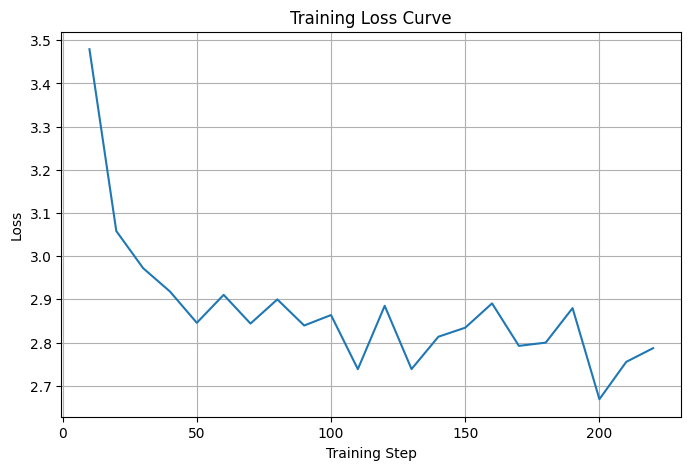

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(steps, losses)

plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("Training Loss Curve")

plt.grid(True)

plt.show()

## A/B Testing

In [17]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

base_model_name = "Qwen/Qwen2.5-0.5B"

base_tokenizer = AutoTokenizer.from_pretrained(base_model_name)

base_model = AutoModelForCausalLM.from_pretrained(
    base_model_name,
    device_map="auto",
    torch_dtype=torch.float16
)

# Before

In [18]:
prompt = "Buatkan resep nasi goreng dalam 5 langkah sederhana"

inputs = base_tokenizer(prompt, return_tensors="pt").to(base_model.device)

outputs = base_model.generate(
    **inputs,
    max_new_tokens=100,
    temperature=0.7,
    top_p=0.9,
    repetition_penalty=1.2,
    do_sample=True
)

base_response = base_tokenizer.decode(outputs[0], skip_special_tokens=True)

print(base_response)

Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


Buatkan resep nasi goreng dalam 5 langkah sederhana dan memang gak susah sekali. Banyak yang suka nasi gorengnya, karena mudah dibuat dan lezat.
Nasi Goreng di Indonesia biasanya disajikan dengan bumbu goreng seperti sayuran, kecap asin atau ayam serta rasa manis dari air hangat. Dengan adanya kandungan ini membuat nasi menjadi lebih enak saat ditambah dengan cemilan lain.

Kami menyediakan jamin


# After

In [19]:
inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

outputs = base_model.generate(
    **inputs,
    max_new_tokens=100,
    temperature=0.7,
    top_p=0.9,
    repetition_penalty=1.2,
    do_sample=True
)

finetuned_response = tokenizer.decode(outputs[0], skip_special_tokens=True)

print(finetuned_response)

Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


Buatkan resep nasi goreng dalam 5 langkah sederhana dan menarik, yang dapat dihidangkan bersama keluarga. Banyak sekali resep nasi goreng yang siap dilihat dan bisa jadi makanan favoritmu.
Sedikit tips agar tidak kacau:
* Jangan terlalu banyak berlebihan pada masakannya
* Saya menggorengnya dengan teflon untuk lebih enak karena panasnya sangat tinggi


#Experiment Bahasa Daerah : Sunda

Load dataset di github yang sudah di buat

In [30]:
#Load Data dari Github data Custom

import json
import requests
from datasets import Dataset

url = "https://raw.githubusercontent.com/zar7364/SFT_LoRA_Nezar-Abdilah-Prakasa-563414/main/data/dataset.json"

response = requests.get(url)
data = response.json()

dataset = Dataset.from_list(data)

print(dataset[0])

{'messages': [{'content': 'Kumaha cara nyieun nasi goreng?', 'role': 'user'}, {'content': 'Panaskeun minyak heula, tuluy tumis bawang jeung cabe nepi ka seungit. Sanggeus éta asupkeun sangu sarta kecap secukupna.', 'role': 'assistant'}]}


# Formatting

In [51]:
def format_chat(example):
    user_msg = example["messages"][0]["content"]
    assistant_msg = example["messages"][1]["content"]

    return {
        "text": f"### Instruction:\n{user_msg}\n\n### Response:\n{assistant_msg}"
    }

formatted_dataset = dataset.map(format_chat)

Map:   0%|          | 0/99 [00:00<?, ? examples/s]

# Hasil-Before

In [32]:
prompt = "Kumaha cara nyieun seblak?"

inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

outputs = model.generate(
    **inputs,
    max_new_tokens=100,
    temperature=0.7,
    top_p=0.9,
    repetition_penalty=1.2,
    do_sample=True
)

before_response = tokenizer.decode(outputs[0], skip_special_tokens=True)

print(before_response)

Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/utils/checkpoint.py:232: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  check_backward_validity(args)


Kumaha cara nyieun seblak? | 10598436
Pertama kali menerima alasan ini adalah akhir-akhir ini saya berpendapat bahwa dalam urusan kesehatan kita tidak perlu mengantarkan sumber daya yang sangat baik seperti keperjayaan hingga kemudahan dan kesempatan. Sementara itu, setiap orang pasti membutuhkan banyak hal yang dapat membantu mereka untuk lebih suksesnya.
Namun terkadang


# Configurasi Training Model

In [37]:
from trl import SFTConfig

training_args=SFTConfig(
    output_dir="./sft-output",
    num_train_epochs=3,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    gradient_checkpointing=True,
    learning_rate=5e-4,
    fp16=True,
    logging_steps=1,
    save_strategy="epoch",
    max_seq_length=256,
)

#Training

In [39]:
trainer=SFTTrainer(
    model=model,
    train_dataset=formatted_dataset,
    args=training_args,
    dataset_text_field="text"
)

trainer.train()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_deprecation.py:100: FutureWarning: Deprecated argument(s) used in '__init__': dataset_text_field. Will not be supported from version '1.0.0'.

Deprecated positional argument(s) used in SFTTrainer, please use the SFTConfig to set these arguments instead.
  warnings.warn(message, FutureWarning)
/usr/local/lib/python3.12/dist-packages/trl/trainer/sft_trainer.py:321: UserWarning: You passed a `dataset_text_field` argument to the SFTTrainer, the value you passed will override the one in the `SFTConfig`.
  warnings.warn(


Map:   0%|          | 0/99 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss
1,4.166400
2,3.761200
3,3.610900
4,3.703300
5,3.502300
6,3.577900
7,3.265900
8,2.716200
9,2.850000
10,3.221400


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


TrainOutput(global_step=36, training_loss=2.723996341228485, metrics={'train_runtime': 44.4148, 'train_samples_per_second': 6.687, 'train_steps_per_second': 0.811, 'total_flos': 27242232956928.0, 'train_loss': 2.723996341228485, 'epoch': 2.88})

#Grafik Training Loss

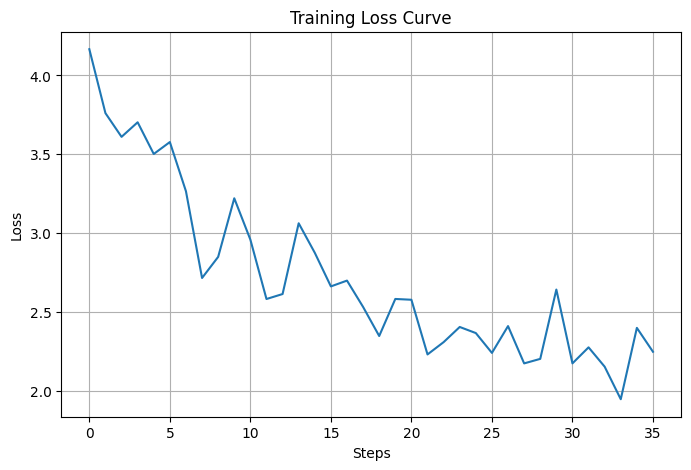

In [40]:
import matplotlib.pyplot as plt

loss_history=[]

for log in trainer.state.log_history:
    if "loss" in log:
        loss_history.append(log["loss"])

plt.figure(figsize=(8,5))
plt.plot(loss_history)
plt.title("Training Loss Curve")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# Hasil - After

In [50]:
prompt="Kumaha cara nyieun seblak?"

inputs=tokenizer(prompt,return_tensors="pt").to(model.device)

outputs=model.generate(
    input_ids=inputs["input_ids"],
    attention_mask=inputs["attention_mask"],
    max_new_tokens=80,
    temperature=0.5,
    top_p=0.9,
    repetition_penalty=1.3,
    do_sample=True
)

result=tokenizer.decode(outputs[0],skip_special_tokens=True)

print("Prompt:")
print(prompt)

print()
print("Hasil Model:")
print(result)

Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


Prompt:
Kumaha cara nyieun seblak?

Hasil Model:
Kumaha cara nyieun seblak? – Rasa nguyahan, kopi jeung cair aneka sayuran dihafal. Namu nikmat jelas ka ena kasar rata gula sambel kuas.
Nikhi tulang lapis ayam segep tetek rebus kecap dan saus sapi yang dicampur cabe hijau, bawang putih & sat


In [ ]:
Pertanyaan Analisis Pada Tugas

Q1. Mengapa base model memiliki pengetahuan luas tetapi lemah dalam mengikuti instruksi?

Karena saat pre-training model hanya belajar memprediksi token berikutnya dari data internet,
bukan belajar mengikuti instruksi pengguna. Jadi model lebih terbiasa melanjutkan teks dibanding menjawab seperti assistant.

Q2. Berapa persen parameter yang Anda latih dengan LoRA dibanding total parameter model? Apa dampaknya terhadap efisiensi?

Berdasarkan hasil training, hanya sekitar 0.2184% parameter yang dilatih menggunakn LoRA,
yaitu 1,081,344 dari total 495,114,112 parameter. Hal ini membuat training lebih efisien dan tetap efektif untuk fine-tuning model.

Q3. Tampilkan 3 contoh respons model sebelum dan sesudah fine-tuning. Analisis perbedaannya.
Sebelum fine-tuning, model cenderung menghasilkan jawaban yang kurang fokus, repetitif, dan tidak mengikuti instruksi dengan baik.
Setelah fine-tuning, respons menjadi lebih relevan, lebih natural, dan lebih sesuai dengan konteks instruksi pengguna.

Q4. Apa risiko overfitting pada dataset kecil? Bagaimana Anda mendeteksi dan mencegahnya?
Risiko overfiting pada dataset kecil adalah model terlalu menghafal data training shingga performa pada prompt baru menjadi buruk.
Cara mendeteksinya bisa dilihat saat training loss turun tetapi kualitas jawaban tidak membaik.
Cara mencegahnya bisa dilakukan dengan menggunakan dataset yang lebih bervariasi

Q5. Jika Anda membuat dataset bahasa daerah sendiri: apa tantangan utama dalam membuat data berkualitas tinggi? Apa yang Anda pelajari?
-Tantangan utamanya adalah membuat percakapan yang lebih variatif dan seperti manusia lebih natural agar menghasilkan output yang natural juga.
Dari proses ini saya belajar bahwa kualitas dataset yang digunakan sangat mempengaruhi output dari model yang digunakan.
